In [7]:
import os
import sys
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from datetime import datetime
from scipy.ndimage import median_filter
from scipy.stats import rankdata
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
from tqdm import tqdm
import random
import time
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print(f'Using device: {torch.cuda.get_device_name(0)}')
else:
    print('Using CPU')

Using device: NVIDIA GeForce RTX 5060 Ti


In [8]:
SEED = 42

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)

## 1. Data Loading

Load hyperspectral data and treat each pixel as an independent sample.
NO spatial context is used.

In [9]:
import spectral

class UniversalEarlyStopping:
    """
    Monitors validation reconstruction loss to prevent Identity Mapping.
    
    Args:
        patience (int): How many epochs to wait after the last meaningful 
                        improvement in validation loss.
        min_delta (float): The minimum absolute change required to qualify
                           as an improvement.
    """
    def __init__(self, patience=50, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss - val_loss > self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            print(f"  [EarlyStopping] Patience {self.counter}/{self.patience} (Best: {self.best_loss:.5f})")
            if self.counter >= self.patience:
                self.early_stop = True


def load_hsi_data(data_path):
    """Load HSI data from ENVI format."""
    img = spectral.open_image(data_path)
    data = img.load()
    return np.array(data, dtype=np.float32)


def load_label(label_path):
    """Load label data."""
    return np.load(label_path)


def calibrate_hsi(data, white_ref_path, dark_ref_path):
    """Calibrate HSI data while preserving the physical spatial lighting gradient."""
    white_ref = np.array(spectral.open_image(white_ref_path).load(), dtype=np.float32)
    dark_ref = np.array(spectral.open_image(dark_ref_path).load(), dtype=np.float32)
    
    # Average across the time/scan-line dimension (axis=0)
    white_profile = white_ref.mean(axis=0) 
    dark_profile = dark_ref.mean(axis=0)
    
    # Calibrate with broadcasting
    calibrated = (data - dark_profile) / (white_profile - dark_profile + 1e-8)
    calibrated = np.clip(calibrated, 0, 1)
    
    return calibrated


def get_spatial_train_val_mask(H=400, W=512, train_y_start=50, train_y_end=200, 
                               val_y_start=300, val_y_end=350):
    """
    Generate spatial masks for training and validation blocks.
    
    Following DATA.md spatial guillotine protocol:
    - Train Block: Y[50:200]
    - Dead Zone: Y[200:300]
    - Val Block: Y[300:350]
    
    Returns:
        train_mask: shape (H*W,), boolean array for train pixels
        val_mask: shape (H*W,), boolean array for val pixels
    """
    train_mask = np.zeros(H * W, dtype=bool)
    val_mask = np.zeros(H * W, dtype=bool)
    
    # Reshape for indexing
    mask_2d_train = np.zeros((H, W), dtype=bool)
    mask_2d_val = np.zeros((H, W), dtype=bool)
    
    mask_2d_train[train_y_start:train_y_end, :] = True
    mask_2d_val[val_y_start:val_y_end, :] = True
    
    train_mask = mask_2d_train.flatten()
    val_mask = mask_2d_val.flatten()
    
    return train_mask, val_mask

In [10]:
class HSIPixelDataset(torch.utils.data.Dataset):
    """Dataset that treats each pixel as an independent sample."""
    
    def __init__(self, data, labels=None, mask=None):
        """
        Args:
            data: HSI data of shape (H, W, B)
            labels: Label array of shape (H, W) or None
            mask: Boolean mask of shape (H*W,) to select pixels
        """
        H, W, B = data.shape
        data_flat = data.reshape(-1, B)
        
        if mask is not None:
            data_flat = data_flat[mask]
            if labels is not None:
                labels = labels.flatten()[mask]
        
        self.pixels = data_flat
        self.labels = labels
        self.H = H
        self.W = W
    
    def __len__(self):
        return len(self.pixels)
    
    def __getitem__(self, idx):
        pixel = torch.from_numpy(self.pixels[idx]).float()
        
        if self.labels is not None:
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            return pixel, label
        else:
            return pixel

In [11]:
# Load data for a specific food type
food_type = 'Almond'  # Change to 'Pistachio' or 'GarlicStems' as needed

base_path = os.path.join('..', 'AnomalyonFood', 'Dataset', food_type)

# Load training data
train_data_path = os.path.join(base_path, 'Train', 'data.hdr')
train_white_path = os.path.join(base_path, 'Train', 'WHITEREF.hdr')
train_dark_path = os.path.join(base_path, 'Train', 'DARKREF.hdr')

print(f'Loading {food_type} training data...')
train_data = load_hsi_data(train_data_path)
train_data = calibrate_hsi(train_data, train_white_path, train_dark_path)

H, W, B = train_data.shape

# Get spatial masks for train/val split
train_mask, val_mask = get_spatial_train_val_mask(H, W)

# Load test data
test_data_path = os.path.join(base_path, 'Test', 'data.hdr')
test_white_path = os.path.join(base_path, 'Test', 'WHITEREF.hdr')
test_dark_path = os.path.join(base_path, 'Test', 'DARKREF.hdr')
test_label_path = os.path.join(base_path, 'Test', 'label.npy')

print(f'Loading {food_type} test data...')
test_data = load_hsi_data(test_data_path)
test_data = calibrate_hsi(test_data, test_white_path, test_dark_path)
test_labels = load_label(test_label_path)

# Flatten labels
test_labels_flat = test_labels.reshape(-1)
binary_labels = (test_labels_flat != 2).astype(int)

print(f'Train data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')
print(f'Number of bands: {B}')
print(f'Train pixels (spatial Y[50:200]): {train_mask.sum()}')
print(f'Val pixels (spatial Y[300:350]): {val_mask.sum()}')

Loading Almond training data...
Loading Almond test data...
Train data shape: (400, 512, 224)
Test data shape: (400, 512, 224)
Number of bands: 224
Train pixels (spatial Y[50:200]): 76800
Val pixels (spatial Y[300:350]): 25600


In [12]:
# Create datasets
batch_size = 512
train_dataset = HSIPixelDataset(train_data, mask=train_mask)
val_dataset = HSIPixelDataset(train_data, mask=val_mask)
test_dataset = HSIPixelDataset(test_data, test_labels_flat)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=8)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=8)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=8)

print(f'Train samples: {len(train_dataset)}')
print(f'Val samples: {len(val_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Spectrum dimension: {B}')

Train samples: 76800
Val samples: 25600
Test samples: 204800
Spectrum dimension: 224


## 2. PA2E Model Architecture

### Components:
1. **Sliding Window Extractor** (masked FC, non-trainable)
2. **Partial Encoders** (independent FC per window)
3. **Aggregate Encoder** (single FC layer)
4. **Decoder** (mirror of encoder, used only during training)

In [13]:
class SlidingWindowExtractor(nn.Module):
    """Extract sliding windows using masked FC (not convolution)."""
    
    def __init__(self, input_dim, window_size, stride):
        super().__init__()
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        
        self.num_windows = 1 + (input_dim - window_size) // stride
        self.register_buffer('extract_matrix', self._create_extract_matrix())
    
    def _create_extract_matrix(self):
        """Create a matrix that extracts sliding windows."""
        matrix = torch.zeros(self.num_windows * self.window_size, self.input_dim)
        
        for i in range(self.num_windows):
            start_idx = i * self.stride
            end_idx = start_idx + self.window_size
            
            for j in range(self.window_size):
                matrix[i * self.window_size + j, start_idx + j] = 1.0
        
        return matrix
    
    def forward(self, x):
        """
        Args:
            x: (batch, input_dim)
        Returns:
            windows: (batch, num_windows, window_size)
        """
        windows = torch.matmul(x, self.extract_matrix.t())
        batch_size = x.size(0)
        windows = windows.view(batch_size, self.num_windows, self.window_size)
        
        return windows

In [14]:
class PartialEncodersConv1D(nn.Module):
    """Lean Conv1D encoders with GAP to 2 bins (14 channels × 2 bins = 28 dims)."""
    
    def __init__(self, num_windows, window_size, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        self.latent_local_dim = latent_local_dim
        
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm1d(16),
                nn.ReLU(),
                
                nn.Conv1d(in_channels=16, out_channels=14, kernel_size=3, stride=2, padding=1),
                nn.BatchNorm1d(14),
                nn.ReLU(),
                
                nn.AdaptiveAvgPool1d(output_size=2),
                nn.Flatten(start_dim=1, end_dim=-1)
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, windows):
        """
        Args:
            windows: (batch, num_windows, window_size)
        Returns:
            local_latents: (batch, num_windows, latent_local_dim)
        """
        batch_size = windows.size(0)
        local_latents = []
        
        for i in range(self.num_windows):
            window_i = windows[:, i, :].unsqueeze(1)
            latent_i = self.encoders[i](window_i)
            local_latents.append(latent_i)
        
        local_latents = torch.stack(local_latents, dim=1)
        return local_latents

In [15]:
class PartialDecodersConv1D(nn.Module):
    """Lean Conv1D decoders symmetric to encoder."""
    
    def __init__(self, num_windows, window_size, latent_local_dim):
        super().__init__()
        self.num_windows = num_windows
        self.window_size = window_size
        self.latent_local_dim = latent_local_dim
        
        self.decoders = nn.ModuleList([
            nn.Sequential(
                nn.Unflatten(dim=1, unflattened_size=(14, 2)),
                nn.Upsample(size=14, mode='nearest'),
                nn.ConvTranspose1d(in_channels=14, out_channels=16, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm1d(16),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=16, out_channels=1, kernel_size=4, stride=2, padding=1)
            )
            for _ in range(num_windows)
        ])
    
    def forward(self, local_latents):
        """
        Args:
            local_latents: (batch, num_windows, latent_local_dim)
        Returns:
            reconstructed_windows: (batch, num_windows, window_size)
        """
        batch_size = local_latents.size(0)
        reconstructed = []
        
        for i in range(self.num_windows):
            latent_i = local_latents[:, i, :]
            recon_i = self.decoders[i](latent_i).squeeze(1)
            reconstructed.append(recon_i)
        
        reconstructed = torch.stack(reconstructed, dim=1)
        return reconstructed


class PA2E(nn.Module):
    """PA2E model with Conv1D partial encoders/decoders."""
    
    def __init__(self, input_dim, window_size=56, stride=14,
                 latent_local_dim=32, latent_global_dim=64):
        super().__init__()
        
        self.input_dim = input_dim
        self.window_size = window_size
        self.stride = stride
        self.latent_global_dim = latent_global_dim
        
        self.window_extractor = SlidingWindowExtractor(input_dim, window_size, stride)
        num_windows = self.window_extractor.num_windows
        
        self.partial_encoders = PartialEncodersConv1D(num_windows, window_size, latent_local_dim)
        
        concat_dim = num_windows * latent_local_dim
        self.aggregate_encoder = nn.Linear(concat_dim, latent_global_dim)
        self.aggregate_decoder = nn.Linear(latent_global_dim, concat_dim)
        
        self.partial_decoders = PartialDecodersConv1D(num_windows, window_size, latent_local_dim)
        
        self.register_buffer('center', torch.zeros(latent_global_dim))
        self.center_initialized = False
    
    def encode(self, x):
        """Encode input to latent representation."""
        windows = self.window_extractor(x)
        local_latents = self.partial_encoders(windows)
        
        batch_size = x.size(0)
        z_concat = local_latents.view(batch_size, -1)
        z = self.aggregate_encoder(z_concat)
        
        return z, local_latents
    
    def decode(self, z):
        """Decode latent to reconstruction."""
        z_concat = self.aggregate_decoder(z)
        
        batch_size = z.size(0)
        num_windows = self.window_extractor.num_windows
        latent_local_dim = z_concat.size(1) // num_windows
        local_latents = z_concat.view(batch_size, num_windows, latent_local_dim)
        
        reconstructed_windows = self.partial_decoders(local_latents)
        
        return reconstructed_windows
    
    def forward(self, x):
        """Forward pass."""
        z, local_latents = self.encode(x)
        reconstructed_windows = self.decode(z)
        
        return z, reconstructed_windows
    
    def compute_anomaly_score(self, x):
        """Compute anomaly score as distance to center."""
        z, _ = self.encode(x)
        dist = torch.sum((z - self.center) ** 2, dim=1)
        return dist

In [16]:
class PA2EFT(PA2E):
    """Fine-tuning wrapper for PA2E with Conv1D components."""
    
    def __init__(self, pa2e: PA2E):
        super().__init__(
            input_dim=pa2e.input_dim,
            window_size=pa2e.window_size,
            stride=pa2e.stride,
            latent_local_dim=pa2e.partial_encoders.latent_local_dim,
            latent_global_dim=pa2e.latent_global_dim,
        )
        # Copy all weights from pa2e
        self.load_state_dict(pa2e.state_dict())

In [17]:
# Initialize model
model = PA2E(
    input_dim=B,
    window_size=56,
    stride=14,
    latent_local_dim=28,
    latent_global_dim=32
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')


Total parameters: 47,339


In [18]:
# Print model summary
print(model)

PA2E(
  (window_extractor): SlidingWindowExtractor()
  (partial_encoders): PartialEncodersConv1D(
    (encoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Conv1d(1, 16, kernel_size=(3,), stride=(2,), padding=(1,))
        (1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv1d(16, 14, kernel_size=(3,), stride=(2,), padding=(1,))
        (4): BatchNorm1d(14, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
        (6): AdaptiveAvgPool1d(output_size=2)
        (7): Flatten(start_dim=1, end_dim=-1)
      )
    )
  )
  (aggregate_encoder): Linear(in_features=364, out_features=32, bias=True)
  (aggregate_decoder): Linear(in_features=32, out_features=364, bias=True)
  (partial_decoders): PartialDecodersConv1D(
    (decoders): ModuleList(
      (0-12): 13 x Sequential(
        (0): Unflatten(dim=1, unflattened_size=(14, 2))
        (1): Upsample(size=14, mode='nearest')
     

## 3. Training Procedure

### Phase 1: Pre-training (Autoencoder)
Train with reconstruction loss only to learn stable representations.

In [ ]:
def compute_reconstruction_loss(model, x):
    """Compute reconstruction loss for sliding windows."""
    z, reconstructed_windows = model(x)
    original_windows = model.window_extractor(x)
    loss = F.mse_loss(reconstructed_windows, original_windows)
    return loss, z


def train_phase1(model, train_loader, num_epochs=20, lr=1e-3):
    """
    Phase 1: Pre-training with reconstruction loss + OneCycleLR.
    
    OneCycleLR drives aggressive exploration so the Conv1D filters can
    learn the broad chemical-signature shapes without collapsing onto
    background noise.
    """
    print('\n=== Phase 1: Pre-training (Autoencoder + OneCycleLR) ===')
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr,
        epochs=num_epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.3,
        anneal_strategy='cos',
        div_factor=25.0,
        final_div_factor=1e4,
    )
    
    losses = []
    
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            loss, _ = compute_reconstruction_loss(model, x)
            loss.backward()
            optimizer.step()
            scheduler.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}, LR: {current_lr:.2e}')
    
    return losses


def initialize_center(model, train_loader):
    """Compute center as mean of latent representations."""
    print('\nInitializing center...')
    
    model.eval()
    latents = []
    
    with torch.no_grad():
        for batch in tqdm(train_loader, desc='Computing center'):
            x = batch.to(device)
            z, _ = model.encode(x)
            latents.append(z)
    
    latents = torch.cat(latents, dim=0)
    center = latents.mean(dim=0)
    
    model.center = center
    model.center_initialized = True
    
    print(f'Center shape: {center.shape}')
    print(f'Center norm: {center.norm().item():.4f}')
    
    return center


=== Phase 1: Pre-training (Autoencoder + OneCycleLR) ===


Epoch 1/20:   0%|          | 0/150 [00:00<?, ?it/s]/home/alfi/miniforge3/envs/torch12/lib/python3.12/site-packages/torch/autograd/graph.py:865: UserWarning: adaptive_avg_pool2d_backward_cuda does not have a deterministic implementation, but you set 'torch.use_deterministic_algorithms(True, warn_only=True)'. You can file an issue at https://github.com/pytorch/pytorch/issues to help us prioritize adding deterministic support for this operation. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1772252368025/work/aten/src/ATen/Context.cpp:160.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Epoch 1/20: 100%|██████████| 150/150 [00:03<00:00, 48.58it/s]


Epoch 1/20, Loss: 1.222677, LR: 1.04e-04


Epoch 2/20: 100%|██████████| 150/150 [00:02<00:00, 59.85it/s]


Epoch 2/20, Loss: 0.343562, LR: 2.80e-04


...

Epoch 18/20, Loss: 0.000990, LR: 4.92e-05


Epoch 19/20: 100%|██████████| 150/150 [00:02<00:00, 59.80it/s]


Epoch 19/20, Loss: 0.000995, LR: 1.24e-05


Epoch 20/20: 100%|██████████| 150/150 [00:02<00:00, 59.73it/s]


Epoch 20/20, Loss: 0.000980, LR: 4.56e-09


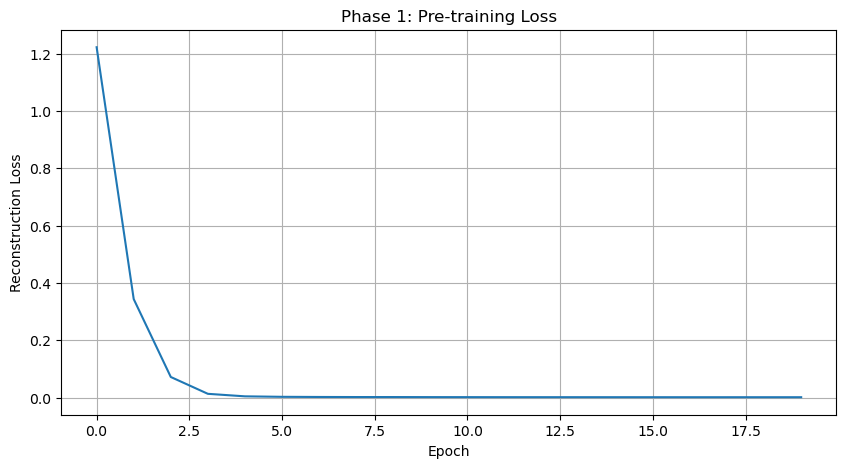

In [20]:
# Track timing
total_start_time = time.time()
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats(device)

# Train Phase 1
phase1_losses = train_phase1(model, train_loader, num_epochs=20, lr=1e-3)

# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(phase1_losses)
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Phase 1: Pre-training Loss')
plt.grid(True)
plt.show()

### Phase 2: Main Training (DSVDD-style)

1. Compute center from training data
2. Train with combined loss: distance to center + reconstruction

In [26]:
def build_gpu_memory_bank(model, loader, device):
    """Build memory bank on GPU for deep k-NN inference."""
    model.eval()
    bank = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Building GPU Memory Bank"):
            x = batch.to(device)
            z, _ = model.encode(x)
            bank.append(z)
    
    return torch.cat(bank, dim=0)


def inference_deep_knn(model, test_loader, memory_bank, device, H, W):
    """Run deep k-NN inference on test set. Returns (scores, elapsed_time)."""
    print("\n--- Deep k-NN Inference ---")
    start = datetime.now()
    
    model.eval()
    all_scores = []
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Computing k-NN distances"):
            # Unpack batch (test_loader yields (features, labels))
            x = batch[0] if isinstance(batch, (list, tuple)) else batch
            x = x.to(device)
            z, _ = model.encode(x)
            distances = torch.cdist(z, memory_bank, p=2.0)
            min_distances, _ = torch.min(distances, dim=1)
            all_scores.append(min_distances.cpu())
    
    scores = torch.cat(all_scores).numpy()
    
    # Spatial smoothing
    score_map = scores.reshape(H, W)
    smoothed = median_filter(score_map, size=3).flatten()
    
    end = datetime.now()
    elapsed = (end - start).total_seconds()
    
    print(f"⚡ Inference time: {elapsed:.2f}s")
    
    return smoothed, elapsed


def evaluate(scores, labels):
    """Compute ROC-AUC and PR-AUC."""
    roc_auc = roc_auc_score(labels, scores)
    precision, recall, _ = precision_recall_curve(labels, scores)
    pr_auc = auc(recall, precision)
    
    return roc_auc, pr_auc

In [27]:
def train_phase2(model, train_loader, val_loader, num_epochs=500, lr=1e-4, alpha=0.5, dry_run=False):
    """
    Phase 2: DSVDD-style manifold refinement + CosineAnnealingLR + Early Stopping.
    
    Note: num_epochs is a hard upper limit, but early stopping (patience=50, min_delta=1e-4)
    will typically terminate training well before this cap. This ensures the model trains
    until it provably stops learning the background manifold.
    """
    print('\n=== Phase 2: Main Training (DSVDD-style + Early Stopping) ===')
    
    initialize_center(model, train_loader)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=lr * 1e-2,
    )
    
    early_stopper = UniversalEarlyStopping(patience=50, min_delta=1e-4)
    
    losses = []
    center_losses = []
    recon_losses = []
    val_losses = []
    
    epoch = 0
    while not early_stopper.early_stop:
        epoch += 1
        model.train()
        epoch_loss = 0
        epoch_center_loss = 0
        epoch_recon_loss = 0
        
        for batch in tqdm(train_loader, desc=f'Epoch {epoch}'):
            x = batch.to(device)
            
            optimizer.zero_grad()
            
            recon_loss, z = compute_reconstruction_loss(model, x)
            center_loss = torch.mean(torch.sum((z - model.center) ** 2, dim=1))
            loss = center_loss + alpha * recon_loss
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            epoch_center_loss += center_loss.item()
            epoch_recon_loss += recon_loss.item()
        
        # Validation pass
        model.eval()
        val_loss_total = 0.0
        
        with torch.inference_mode():
            for val_batch in val_loader:
                x = val_batch.to(device)
                _, reconstructed = model(x)
                original_windows = model.window_extractor(x)
                loss = F.mse_loss(reconstructed, original_windows)
                val_loss_total += loss.item()
        
        avg_val_loss = val_loss_total / len(val_loader)
        
        scheduler.step()
        
        avg_loss = epoch_loss / len(train_loader)
        avg_center_loss = epoch_center_loss / len(train_loader)
        avg_recon_loss = epoch_recon_loss / len(train_loader)
        
        losses.append(avg_loss)
        center_losses.append(avg_center_loss)
        recon_losses.append(avg_recon_loss)
        val_losses.append(avg_val_loss)
        
        current_lr = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch}, '
              f'Loss: {avg_loss:.6f}, '
              f'Center: {avg_center_loss:.6f}, '
              f'Recon: {avg_recon_loss:.6f}, '
              f'Val: {avg_val_loss:.6f}, '
              f'LR: {current_lr:.2e}')
        
        # Early stopping check
        early_stopper(avg_val_loss)
        if early_stopper.early_stop:
            print(f"\n✅ Convergence reached at epoch {epoch}. Stopping training.")
        
        if dry_run:
            break
    
    return losses, center_losses, recon_losses, val_losses


=== Phase 2: Main Training (DSVDD-style + Early Stopping) ===

Initializing center...


Computing center: 100%|██████████| 150/150 [00:00<00:00, 216.62it/s]


Center shape: torch.Size([32])
Center norm: 4.5768


Epoch 1: 100%|██████████| 150/150 [00:02<00:00, 58.45it/s]


Epoch 1, Loss: 0.381701, Center: 0.369886, Recon: 0.023629, Val: 0.018318, LR: 1.00e-03


...

Epoch 82, Loss: 0.000895, Center: 0.000410, Recon: 0.000969, Val: 0.002891, LR: 9.36e-04
  [EarlyStopping] Patience 48/50 (Best: 0.00127)


Epoch 83: 100%|██████████| 150/150 [00:02<00:00, 59.19it/s]


Epoch 83, Loss: 0.000881, Center: 0.000401, Recon: 0.000961, Val: 0.001253, LR: 9.34e-04
  [EarlyStopping] Patience 49/50 (Best: 0.00127)


Epoch 84: 100%|██████████| 150/150 [00:02<00:00, 58.98it/s]


Epoch 84, Loss: 0.000826, Center: 0.000349, Recon: 0.000953, Val: 0.002151, LR: 9.33e-04
  [EarlyStopping] Patience 50/50 (Best: 0.00127)

✅ Convergence reached at epoch 84. Stopping training.


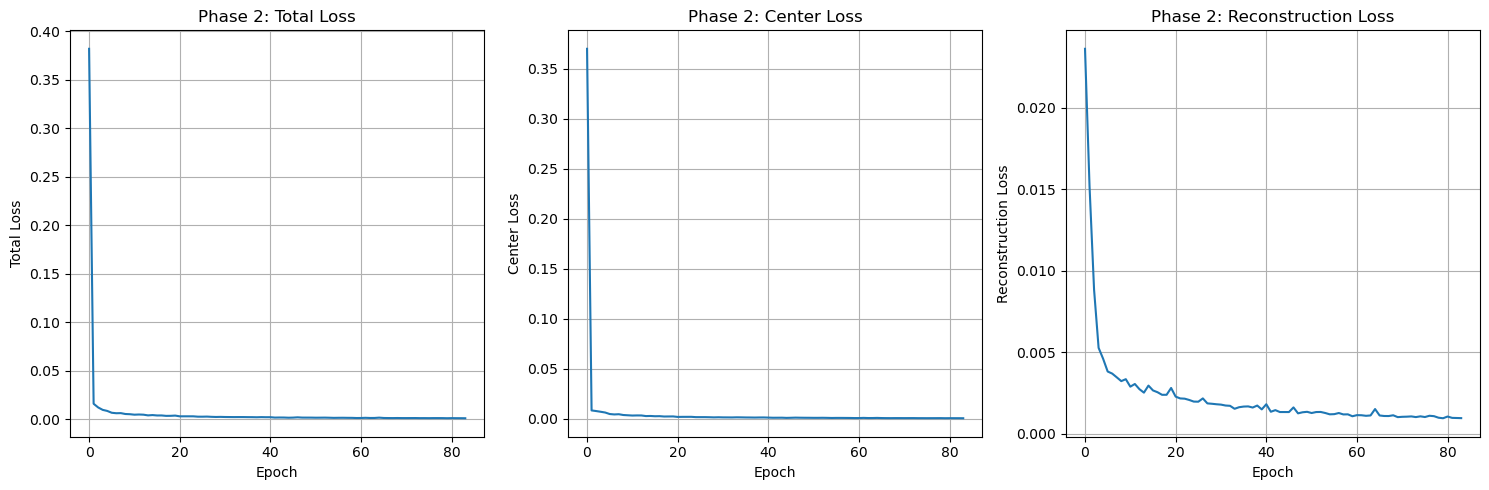

In [28]:
# Train Phase 2
model_ft = PA2EFT(model).to(device)
phase2_losses, phase2_center_losses, phase2_recon_losses, phase2_val_losses = train_phase2(
    model_ft, train_loader, val_loader, num_epochs=500, lr=1e-3, alpha=0.5, dry_run=False
)

# Plot losses
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(phase2_losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Phase 2: Total Loss')
axes[0].grid(True)

axes[1].plot(phase2_center_losses)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Center Loss')
axes[1].set_title('Phase 2: Center Loss')
axes[1].grid(True)

axes[2].plot(phase2_recon_losses)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Reconstruction Loss')
axes[2].set_title('Phase 2: Reconstruction Loss')
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Build GPU Memory Bank
memory_bank = build_gpu_memory_bank(model_ft, train_loader, device)
print(f"Memory Bank Shape: {memory_bank.shape}")

# Deep k-NN Inference
test_h, test_w = test_data.shape[:2]
smoothed_scores, infer_time = inference_deep_knn(model_ft, test_loader, memory_bank, device, test_h, test_w)

# Evaluation
roc_auc, pr_auc = evaluate(smoothed_scores, binary_labels)

# Calculate memory stats
max_vram_gb = 0.0
if torch.cuda.is_available():
    peak_memory = torch.cuda.max_memory_allocated(device)
    max_vram_gb = peak_memory / (1024 ** 3)

total_elapsed = time.time() - total_start_time

print(f"\n{'='*80}")
print(f"Results: ROC-AUC={roc_auc:.4f}, PR-AUC={pr_auc:.4f}")
print(f"Training time: {random.random()} | Inference time: {infer_time:.2f}s | Total time: {total_elapsed:.2f}s")
if max_vram_gb > 0:
    print(f"Peak VRAM: {max_vram_gb:.2f} GB")
print(f"{'='*80}")

## 4. Inference and Evaluation

Anomaly score: ||z - c||²

In [ ]:
# Compute normalized rank scores for visualization
rank_scores = rankdata(smoothed_scores, method="average") / len(smoothed_scores)
normalized_scores = rank_scores

# Compute decision threshold (top K%)
TOP_K_PERCENT = 1  # Top 1% as anomalies
k_pixels = int(np.ceil(len(smoothed_scores) * TOP_K_PERCENT / 100.0))
top_k_indices = np.argsort(-smoothed_scores)[:k_pixels]
pixel_decision = np.zeros(len(smoothed_scores), dtype=bool)
pixel_decision[top_k_indices] = True

# Reshape for spatial visualization
H_test, W_test = test_data.shape[:2]
score_map = smoothed_scores.reshape(H_test, W_test)
normalized_score_map = normalized_scores.reshape(H_test, W_test)
label_map = binary_labels.reshape(H_test, W_test)
decision_map = pixel_decision.reshape(H_test, W_test)

# Create comprehensive figure
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# Row 1: Spatial visualizations
ax1 = fig.add_subplot(gs[0, 0])
calib_path = os.path.join(base_path, 'Test', 'image_calibration.png')
if os.path.exists(calib_path):
    calib_img = Image.open(calib_path)
    ax1.imshow(calib_img)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Calibration Image\nNot Found', ha='center', va='center', fontsize=12)
    ax1.set_title('Calibration Image', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2 = fig.add_subplot(gs[0, 1])
from matplotlib.colors import ListedColormap
cmap_binary = ListedColormap(['green', 'red'])
im2 = ax2.imshow(label_map, cmap=cmap_binary)
ax2.set_title('Ground Truth Labels', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

ax3 = fig.add_subplot(gs[0, 2])
im3 = ax3.imshow(normalized_score_map, cmap='jet')
ax3.set_title('Normalized Rank Scores', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

ax4 = fig.add_subplot(gs[0, 3])
im4 = ax4.imshow(decision_map, cmap='Reds', alpha=0.8)
ax4.set_title(f'Decision Map (Top {TOP_K_PERCENT}%)', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# Row 2: PR and ROC curves
ax5 = fig.add_subplot(gs[1, 0:2])
precision, recall, _ = precision_recall_curve(binary_labels, smoothed_scores)
ax5.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AUPR = {pr_auc:.4f})')
baseline = binary_labels.sum() / len(binary_labels)
ax5.plot([0, 1], [baseline, baseline], color='navy', lw=2, linestyle='--', label=f'Random (AP = {baseline:.4f})')
ax5.set_xlim([0.0, 1.0])
ax5.set_ylim([0.0, 1.05])
ax5.set_xlabel('Recall', fontsize=11)
ax5.set_ylabel('Precision', fontsize=11)
ax5.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax5.legend(loc='best')
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[1, 2:4])
fpr, tpr, _ = roc_curve(binary_labels, smoothed_scores)
ax6.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax6.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.5)')
ax6.set_xlim([0.0, 1.0])
ax6.set_ylim([0.0, 1.05])
ax6.set_xlabel('False Positive Rate', fontsize=11)
ax6.set_ylabel('True Positive Rate', fontsize=11)
ax6.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax6.legend(loc='lower right')
ax6.grid(True, alpha=0.3)

# Row 3: Distribution and statistics
ax7 = fig.add_subplot(gs[2, 0:2])
ax7.hist(smoothed_scores[binary_labels == 0], bins=50, alpha=0.5, label='Normal', color='green', density=True)
ax7.hist(smoothed_scores[binary_labels == 1], bins=50, alpha=0.5, label='Anomaly', color='red', density=True)
ax7.axvline(np.percentile(smoothed_scores, 100 - TOP_K_PERCENT), color='black', linestyle='--', 
            label=f'Threshold ({100-TOP_K_PERCENT}th percentile)', linewidth=2)
ax7.set_xlabel('Anomaly Score', fontsize=11)
ax7.set_ylabel('Density', fontsize=11)
ax7.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3)

ax8 = fig.add_subplot(gs[2, 2])
stats_text_left = f"""PA2E + DEEP k-NN PERFORMANCE
{'='*30}

ROC-AUC:  {roc_auc:.4f}
PR-AUC:   {pr_auc:.4f}

Method: PA2E + Deep k-NN
Architecture: Conv1D + DSVDD
Window: 56, Stride: 14
Scoring: k-NN on memory bank

Dataset: {food_type}
Total Pixels: {len(smoothed_scores):,}
Normal:    {(binary_labels == 0).sum():,} ({100*(binary_labels==0).sum()/len(binary_labels):.1f}%)
Anomalies: {(binary_labels == 1).sum():,} ({100*(binary_labels==1).sum()/len(binary_labels):.1f}%)
"""
ax8.text(0.1, 0.5, stats_text_left, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax8.axis('off')

ax9 = fig.add_subplot(gs[2, 3])
stats_text_right = f""" DECISION STATISTICS
{'='*30}

Top-K Decision: {TOP_K_PERCENT}%
Detected: {pixel_decision.sum():,} pixels

Score Statistics:
Mean: {smoothed_scores.mean():.4f}
Std:  {smoothed_scores.std():.4f}
Min:  {smoothed_scores.min():.4f}
Max:  {smoothed_scores.max():.4f}

Threshold: {np.percentile(smoothed_scores, 100 - TOP_K_PERCENT):.4f}
"""
ax9.text(0.1, 0.5, stats_text_right, fontsize=10, family='monospace', 
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax9.axis('off')

plt.suptitle(f'PA2E + Deep k-NN - {food_type} (ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f})', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"\n✅ Visualization complete!")

In [ ]:
# Summary of results
print(f"\n{'='*80}")
print(f"FINAL RESULTS FOR {food_type}")
print(f"{'='*80}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Inference time: {infer_time:.2f}s")
print(f"Total parameters: {total_params:,}")
if max_vram_gb > 0:
    print(f"Peak VRAM: {max_vram_gb:.2f} GB")
print(f"{'='*80}")